In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [17]:
df = pd.read_csv(r"C:\Users\SHREE HARINI\Downloads\archive (1)\tourism_dataset.csv")

In [18]:
print(df.shape)

(5989, 7)


In [19]:
print(df.head())

     Location Country    Category  Visitors  Rating    Revenue  \
0  kuBZRkVsAR   India      Nature    948853    1.32   84388.38   
1  aHKUXhjzTo     USA  Historical    813627    2.01  802625.60   
2  dlrdYtJFTA  Brazil      Nature    508673    1.42  338777.11   
3  DxmlzdGkHK  Brazil  Historical    623329    1.09  295183.60   
4  WJCCQlepnz  France    Cultural    124867    1.43  547893.24   

  Accommodation_Available  
0                     Yes  
1                      No  
2                     Yes  
3                     Yes  
4                      No  


In [20]:
print(df.isnull().sum())

Location                   0
Country                    0
Category                   0
Visitors                   0
Rating                     0
Revenue                    0
Accommodation_Available    0
dtype: int64


In [21]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [22]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5989, 7)


In [23]:
print(df.dtypes)

Location                    object
Country                     object
Category                    object
Visitors                     int64
Rating                     float64
Revenue                    float64
Accommodation_Available     object
dtype: object


In [24]:
df["Revenue_per_Visitor"] = df["Revenue"] / df["Visitors"]

print(df[["Visitors", "Revenue", "Revenue_per_Visitor"]].head())

   Visitors    Revenue  Revenue_per_Visitor
0    948853   84388.38             0.088937
1    813627  802625.60             0.986479
2    508673  338777.11             0.666002
3    623329  295183.60             0.473560
4    124867  547893.24             4.387815


In [25]:
print(df.head())

     Location Country    Category  Visitors  Rating    Revenue  \
0  kuBZRkVsAR   India      Nature    948853    1.32   84388.38   
1  aHKUXhjzTo     USA  Historical    813627    2.01  802625.60   
2  dlrdYtJFTA  Brazil      Nature    508673    1.42  338777.11   
3  DxmlzdGkHK  Brazil  Historical    623329    1.09  295183.60   
4  WJCCQlepnz  France    Cultural    124867    1.43  547893.24   

  Accommodation_Available  Revenue_per_Visitor  
0                     Yes             0.088937  
1                      No             0.986479  
2                     Yes             0.666002  
3                     Yes             0.473560  
4                      No             4.387815  


In [26]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5989 entries, 0 to 5988
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Location                 5989 non-null   object 
 1   Country                  5989 non-null   object 
 2   Category                 5989 non-null   object 
 3   Visitors                 5989 non-null   int64  
 4   Rating                   5989 non-null   float64
 5   Revenue                  5989 non-null   float64
 6   Accommodation_Available  5989 non-null   object 
 7   Revenue_per_Visitor      5989 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 374.4+ KB
None


In [27]:
print(df.describe())

            Visitors       Rating        Revenue  Revenue_per_Visitor
count    5989.000000  5989.000000    5989.000000          5989.000000
mean   501016.089497     3.009347  499479.367253             3.624295
std    289783.294978     1.155980  286743.225211            18.763034
min      1108.000000     1.000000    1025.810000             0.001350
25%    252789.000000     2.010000  251410.450000             0.502985
50%    500831.000000     3.000000  494169.350000             1.005356
75%    751371.000000     4.010000  742241.240000             2.000396
max    999982.000000     5.000000  999999.490000           784.127343


In [28]:
# Display destinations with more than 500,000 visitors
filtered_df = df[df["Visitors"] > 500000]

print(filtered_df)

        Location    Country    Category  Visitors  Rating    Revenue  \
0     kuBZRkVsAR      India      Nature    948853    1.32   84388.38   
1     aHKUXhjzTo        USA  Historical    813627    2.01  802625.60   
2     dlrdYtJFTA     Brazil      Nature    508673    1.42  338777.11   
3     DxmlzdGkHK     Brazil  Historical    623329    1.09  295183.60   
7     TjmJpYuNne      China  Historical    652046    2.50  796172.02   
...          ...        ...         ...       ...     ...        ...   
5981  MVTceGBxlc        USA    Cultural    568744    4.10  597514.35   
5983  nfYIpSMXeV  Australia       Urban    563437    4.83  652895.17   
5984  xAzwnVKAqz        USA       Urban    828137    1.97  132848.78   
5986  bPyubCWGgA      Egypt       Beach    809198    3.37  927336.50   
5987  kkWIucpBnu      Egypt    Cultural    808303    2.52  115791.43   

     Accommodation_Available  Revenue_per_Visitor  
0                        Yes             0.088937  
1                         No   

In [29]:
# Calculate correlation between numerical columns
correlation = df[["Visitors", "Rating", "Revenue", "Revenue_per_Visitor"]].corr()

print(correlation)

                     Visitors    Rating   Revenue  Revenue_per_Visitor
Visitors             1.000000 -0.010337  0.008358            -0.242141
Rating              -0.010337  1.000000  0.000574             0.010409
Revenue              0.008358  0.000574  1.000000             0.114047
Revenue_per_Visitor -0.242141  0.010409  0.114047             1.000000


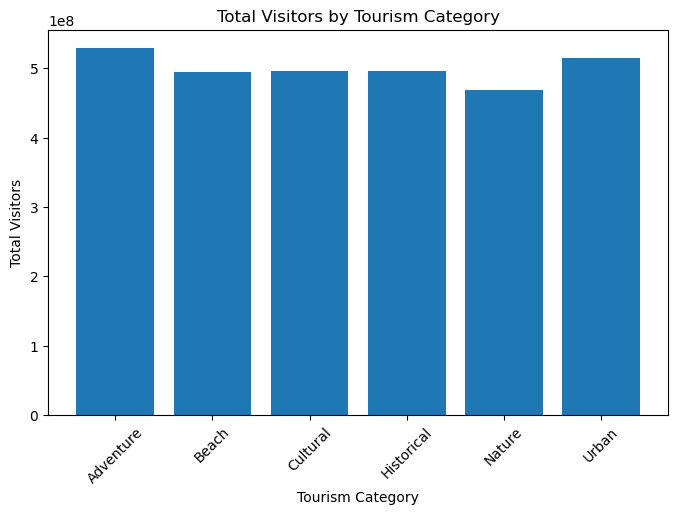

In [30]:
# Count visitors for each tourism category
category_visitors = df.groupby("Category")["Visitors"].sum()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(category_visitors.index, category_visitors.values)

plt.title("Total Visitors by Tourism Category")
plt.xlabel("Tourism Category")
plt.ylabel("Total Visitors")
plt.xticks(rotation=45)

plt.show()

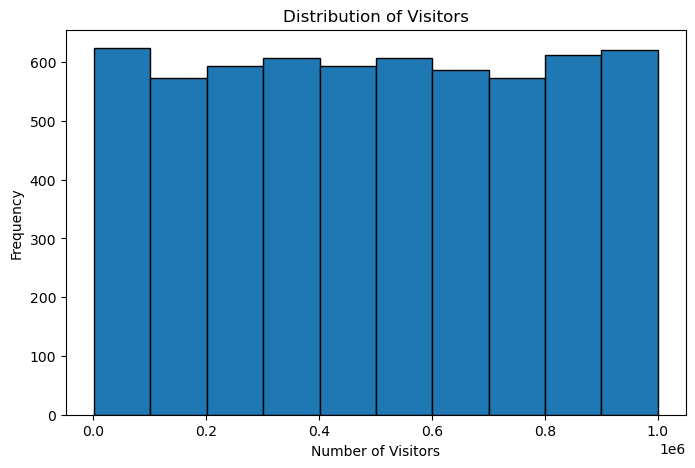

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(df["Visitors"], bins=10, edgecolor="black")

plt.title("Distribution of Visitors")
plt.xlabel("Number of Visitors")
plt.ylabel("Frequency")

plt.show()

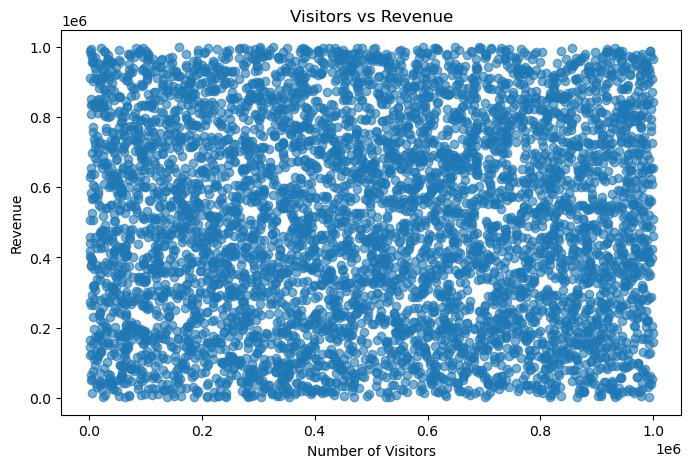

In [32]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Visitors"], df["Revenue"], alpha=0.6)

plt.title("Visitors vs Revenue")
plt.xlabel("Number of Visitors")
plt.ylabel("Revenue")

plt.show()

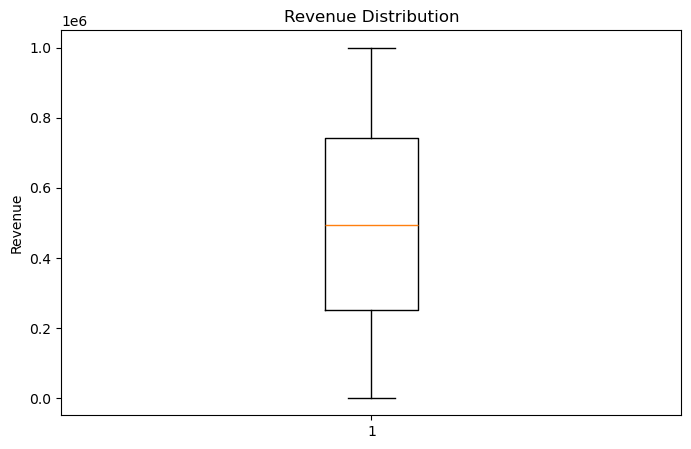

In [33]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Revenue"])

plt.title("Revenue Distribution")
plt.ylabel("Revenue")

plt.show()

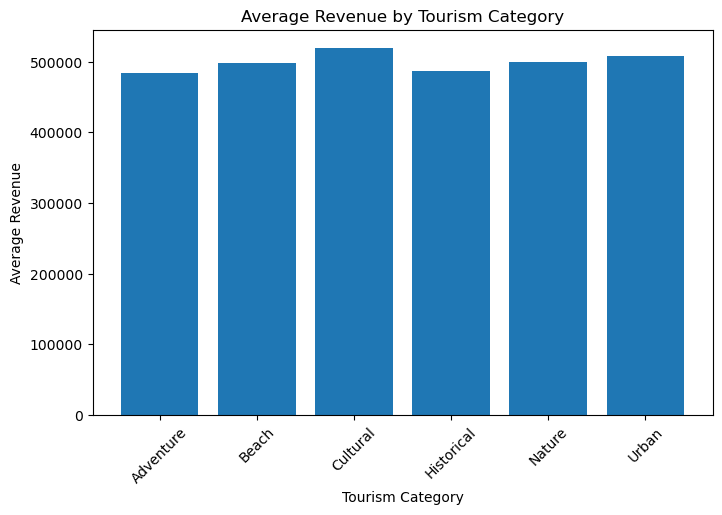

In [34]:
# Calculate average revenue for each category
avg_revenue = df.groupby("Category")["Revenue"].mean()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(avg_revenue.index, avg_revenue.values)

plt.title("Average Revenue by Tourism Category")
plt.xlabel("Tourism Category")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)

plt.show()

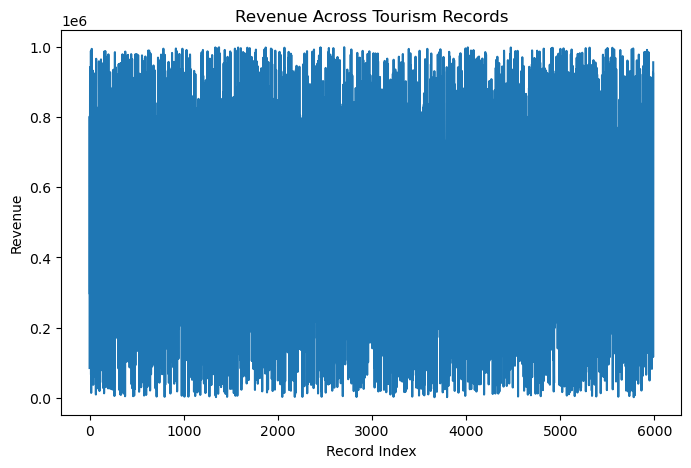

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(df.index, df["Revenue"])

plt.title("Revenue Across Tourism Records")
plt.xlabel("Record Index")
plt.ylabel("Revenue")

plt.show()

In [36]:
df.to_csv("tourism_dataset_cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
